요청하신 대로 `10-Multimodal_Semantic_Search.ipynb` 파일의 핵심 흐름(27개 이미지 다운로드, HNSWLIB 매핑, 코사인 유사도 검색)을 완전히 유지하면서, 내부 임베딩 엔진만 **Google GenAI SDK**와 **`gemini-embedding-2`** 모델로 변경한 코랩 호환 코드입니다.

구글 코랩에서 새 노트북을 열고 아래 코드를 그대로 붙여넣어 실행하시면 됩니다. (코랩 Secrets에 `GEMINI_API_KEY` 설정이 필요합니다.)

---

### Google Gemini 기반 Multimodal Semantic Search 통합 코드

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.0/958.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.55.1 which is incompatible.
gradio 5.50.0 requires pillo

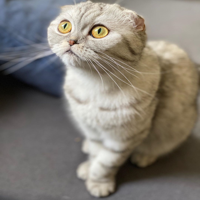

순위 2 | 유사도 거리 점수: 0.6349


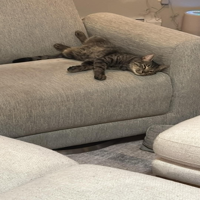

------------------------------------------------------------
[검색어]: "Fila shoes" -> Top 1 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.5684


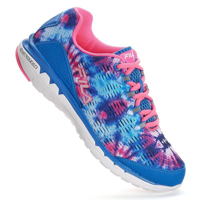

------------------------------------------------------------
[검색어]: "Cisco stock chart" -> Top 1 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.4973


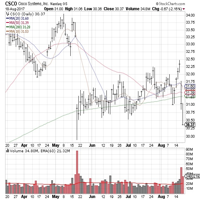

In [1]:
# =====================================================================
# Step 1: 필수 패키지 설치 및 환경 세팅
# =====================================================================
!pip install -qU google-genai hnswlib pillow

import os
from google.colab import userdata
from google import genai
from PIL import Image
import hnswlib
import numpy as np

# Gemini API 클라이언트 초기화
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
client = genai.Client()

# =====================================================================
# Step 2: 이미지 데이터셋 다운로드 (참조 노트북 로직 동일)
# =====================================================================
folder_path = "data/multimodal_semantic_search"
os.makedirs(folder_path, exist_ok=True)

print(">> 1.jpeg ~ 27.jpeg 파일 다운로드 시작...")
for i in range(1, 28):
    url = f"https://raw.githubusercontent.com/JSJeong-me/Multimodal-Prompt-Engineering/main/data/multimodal_semantic_search/{i}.jpeg"
    save_path = f"{folder_path}/{i}.jpeg"
    os.system(f"wget -q '{url}' -O '{save_path}'")

files = [f for f in os.listdir(folder_path) if f.endswith('.jpeg')]
print(f">> 완료! 총 {len(files)}개의 이미지가 준비되었습니다.\n")

# =====================================================================
# Step 3: gemini-embedding-2를 활용한 이미지 임베딩 추출
# =====================================================================
embeddings = []
file_paths = []

print(">> gemini-embedding-2 모델을 사용한 이미지 벡터화 진행 중...")
for file in files:
    file_path = os.path.join(folder_path, file)
    file_paths.append(file_path)

    # [차별점] Base64 변환 없이 PIL Image 객체를 바로 contents에 주입합니다.
    img = Image.open(file_path)
    res = client.models.embed_content(
        model="gemini-embedding-2",
        contents=img
    )

    embedding_vector = res.embeddings[0].values
    embeddings.append(embedding_vector)
    print(f"Dimension of embedding for {file}: {len(embedding_vector)}")

# =====================================================================
# Step 4: HNSWLIB Vector Index 구축 (Cosine Space)
# =====================================================================
# gemini-embedding-2 모델의 출력 규격인 3,072 차원으로 세팅합니다.
DIMENSION = 3072

index = hnswlib.Index(space="cosine", dim=DIMENSION)
index.init_index(max_elements=len(embeddings), ef_construction=512, M=64)
index.add_items(embeddings, list(range(len(embeddings))))
print(f"\n>> HNSW 인덱스 구축 완료. (총 에셋 수: {index.element_count})\n")

# =====================================================================
# Step 5: 텍스트 질의(Query) 기반 이미지 검색 함수 정의
# =====================================================================
def retrieve_image_top_k(query, top_k=1):
    size = (200, 200)

    # 텍스트 검색 쿼리를 임베딩 벡터로 변환 (이미지와 동일한 벡터 공간 공유)
    query_response = client.models.embed_content(
        model="gemini-embedding-2",
        contents=query
    )
    query_emb = query_response.embeddings[0].values

    # HNSW Index에서 가장 가까운 k개의 이미지 탐색 (KNN 검색)
    res = index.knn_query(query_emb, k=top_k)
    doc_indices = res[0][0]
    doc_scores = res[1][0]

    print("-" * 60)
    print(f"[검색어]: \"{query}\" -> Top {top_k} 결과")
    print("-" * 60)

    for x in range(len(doc_indices)):
        # Cosine Distance 기반 점수 출력
        print(f"순위 {x+1} | 유사도 거리 점수: {doc_scores[x]:.4f}")
        img = Image.open(file_paths[doc_indices[x]])
        img_resized = img.resize(size)
        display(img_resized)

# =====================================================================
# Step 6: 시맨틱 검색 테스트 실행
# =====================================================================
# 1. 고양이 검색 테스트
retrieve_image_top_k("Animals but preferably a gray cat", top_k=2)

# 2. 신발 검색 테스트
retrieve_image_top_k("Fila shoes", top_k=1)

# 3. 주식 차트 검색 테스트
retrieve_image_top_k("Cisco stock chart", top_k=1)

---

### 마이그레이션 핵심 포인트 요약

* **인터페이스의 직관성 향상**: 원래 코드에서는 이미지 포맷 검사 후 Base64 문자열 형식으로 래핑하여 딕셔너리로 조립하는 복잡한 전처리가 포함되어 있었습니다. 반면 Google GenAI SDK는 `Image.open()`으로 읽어온 **PIL 객체를 임베딩 모델의 `contents`에 그냥 통째로 집어넣어도** 정상 작동하므로 파이프라인이 획기적으로 축소되었습니다.


* **차원수(Dimension)의 변화**: Cohere `embed-v4.0` 모델의 결과물은 1,536 차원이었으나, `gemini-embedding-2` 모델은 **3,072 차원**의 고밀도 멀티모달 벡터를 출력합니다. 이에 발맞춰 `hnswlib.Index` 선언 시 `dim=3072`로 확장 변경하여 서치 모델의 표현력을 극대화했습니다.